# Embedding Visualization (PCA + t-SNE)

This notebook mirrors the data pipeline from `experiment/new.ipynb` but **does not train** any model.
It extracts embeddings and plots PCA/t-SNE, with optional feature selection to compare results.


In [26]:
# Enable autoreload so edits to modules are picked up without restarting the kernel
%load_ext autoreload
%autoreload 2
## Utils to read data

from enum import Enum
from pathlib import Path
import sys



DATA_PATH_PREFIX = Path.cwd() / "data/SAMD21_Fan_Demo-"

# go to project root
root = str(Path.cwd().parent)
sys.path.append(root)
print("Root: ", root)

class DataType(Enum):
    Normal = 1
    Blocked = 2
    Interference = 3
    OFF = 4


def get_data_path(datatype: DataType, index: int):

    if datatype == DataType.Interference:
        strcode = "Blade Interference"
    
    elif datatype == DataType.Normal:
        strcode = "Fan ON"
    
    elif datatype == DataType.Blocked:
        strcode = "Blocked Flow"
    
    elif datatype == DataType.OFF:
        strcode = "Fan OFF"
    
    postfix = strcode + f"_{index:03d}" + ".csv"
    return str(DATA_PATH_PREFIX) + postfix




The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Root:  /home/btanady/fourth_year/cpen491


In [27]:
from fdd_system.ML.common.config import OperatingCondition
from experiment.utils import prepare_training_data
from pathlib import Path
import os
import numpy as np

DATA_PATH = Path("data_13")
REMOVE_FIRST_SECOND = 2

# Discover files
normal_path = DATA_PATH / "normal"
blocked_path = DATA_PATH / "blocked"
interfere_path = DATA_PATH / "interfere"

INTERFERE_LABEL = OperatingCondition.BLADE_ISSUE.value

NORMAL_FILES = sorted([os.path.join(normal_path, f) for f in os.listdir(normal_path) if f.endswith(".csv")])
BLOCKED_FILES = sorted([os.path.join(blocked_path, f) for f in os.listdir(blocked_path) if f.endswith(".csv")])
INTERFERE_FILES = (
    sorted([os.path.join(interfere_path, f) for f in os.listdir(interfere_path) if f.endswith(".csv")])
    if interfere_path is not None else []
)

training_data_full = {
    OperatingCondition.NORMAL.value: NORMAL_FILES,
    OperatingCondition.BLOCKED_AIRFLOW.value: BLOCKED_FILES,
    INTERFERE_LABEL: INTERFERE_FILES,
}

INCLUDE = {
    OperatingCondition.BLADE_ISSUE,
    OperatingCondition.BLOCKED_AIRFLOW,
    OperatingCondition.NORMAL,
}
training_data_full = {
    cond.value: training_data_full.get(cond.value, [])
    for cond in INCLUDE
}

windows_full = prepare_training_data(training_data_full, shuffle=True, col_names=["X", "Y", "Z"])
print(f"Windows: {len(windows_full)}")


Windows: 1776


In [28]:
from fdd_system.ML.common.preprocessor import *
from fdd_system.ML.common.embedder import MLEmbedder1, MLEmbedder2
from fdd_system.ML.common.config import SensorConfig

# Preprocessor
# pre = DummyPreprocessor()
# pre = MedianRemoval()
pre = StandardZNormal()
# pre = RMSNormalization()

# Embedder
# embedder = MLEmbedder1()
embedder = MLEmbedder2(highpass_hz=10)
# embedder = MLEmbedder1()

pre_full = pre.preprocess(windows_full)
X_full = np.asarray(embedder.embed(pre_full))
y_full = np.array([w.label for w in pre_full], dtype=int)
print(f"Embeddings: {X_full.shape}")


Embeddings: (1776, 72)


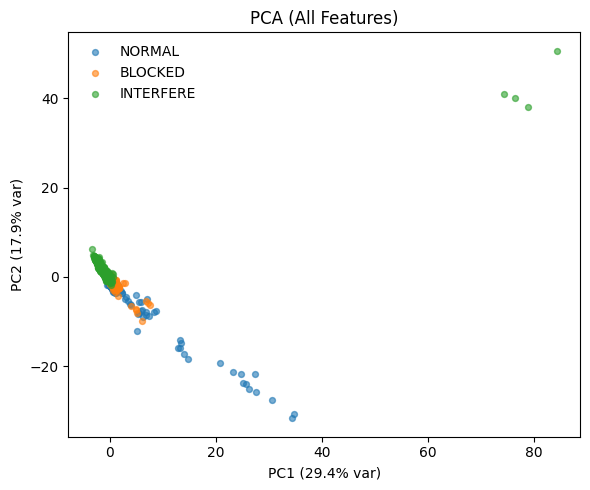

Selected 18 / 72 features using fisher


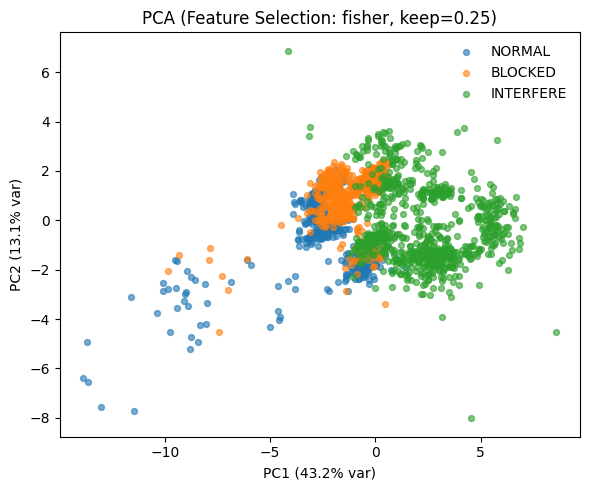

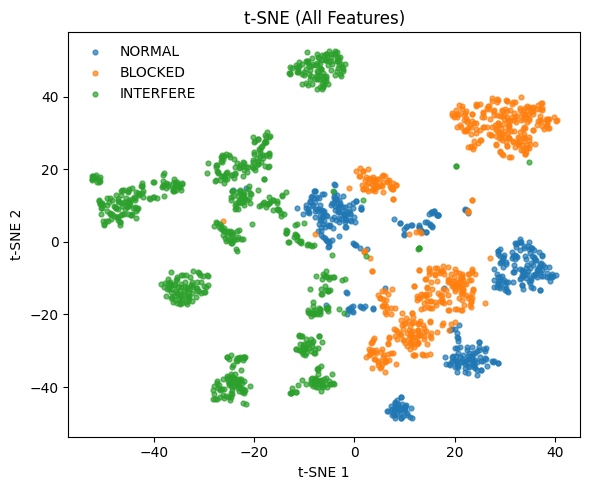

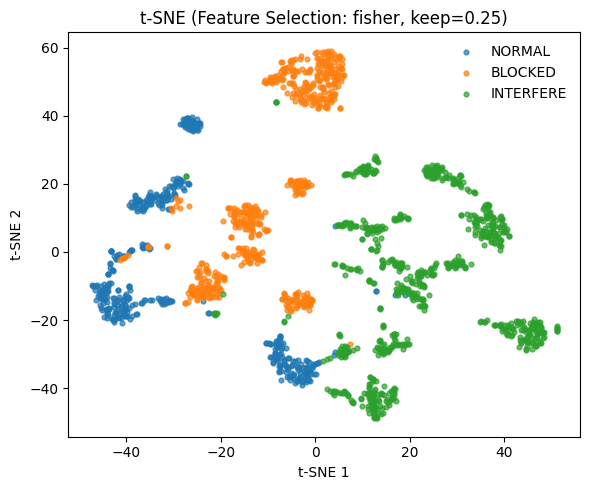

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.feature_selection import mutual_info_classif

# ---- Feature selection options ----
FEATURE_SELECTION = True
METHOD = "fisher"  # fisher | mi
PRESERVE_RATIO = 0.25  # fraction of features to keep

label_map = {0: "NORMAL", 1: "BLOCKED", 2: "INTERFERE"}

def fisher_score(X, y, eps=1e-12):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y)
    classes = np.unique(y)
    overall_mean = np.mean(X, axis=0)
    num = np.zeros(X.shape[1], dtype=float)
    den = np.zeros(X.shape[1], dtype=float)
    for cls in classes:
        Xc = X[y == cls]
        if Xc.size == 0:
            continue
        n_c = Xc.shape[0]
        mu_c = np.mean(Xc, axis=0)
        var_c = np.var(Xc, axis=0)
        num += n_c * (mu_c - overall_mean) ** 2
        den += n_c * var_c
    scores = num / (den + eps)
    return scores

def select_features(X, y, method="fisher", ratio=0.25):
    n_features = X.shape[1]
    k = max(1, int(np.ceil(ratio * n_features)))
    method = method.lower()
    if method == "fisher":
        scores = fisher_score(X, y)
    elif method == "mi":
        scores = mutual_info_classif(X, y, random_state=42)
    else:
        raise ValueError(f"Unknown METHOD: {method}")
    idx = np.argsort(scores)[::-1][:k]
    return X[:, idx], idx, scores

def plot_pca(X, y, title):
    if X.size == 0:
        print("No data to plot.")
        return
    Xs = StandardScaler().fit_transform(X)
    pca = PCA(n_components=2)
    Z = pca.fit_transform(Xs)
    evr = pca.explained_variance_ratio_
    plt.figure(figsize=(6, 5))
    for cls in np.unique(y):
        m = (y == cls)
        plt.scatter(Z[m, 0], Z[m, 1], s=18, label=label_map.get(int(cls), str(cls)), alpha=0.6)
    plt.xlabel(f"PC1 ({evr[0]*100:.1f}% var)")
    plt.ylabel(f"PC2 ({evr[1]*100:.1f}% var)")
    plt.title(title)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

def plot_tsne(X, y, title):
    if X.size == 0:
        print("No data to plot.")
        return
    Xs = StandardScaler().fit_transform(X)
    tsne = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate="auto",
        init="pca",
        max_iter=1000,
        random_state=42,
    )
    Z = tsne.fit_transform(Xs)
    plt.figure(figsize=(6, 5))
    for cls in np.unique(y):
        m = (y == cls)
        plt.scatter(Z[m, 0], Z[m, 1], s=12, label=label_map.get(int(cls), str(cls)), alpha=0.7)
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.title(title)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

# ---- PCA: baseline then feature selection ----
plot_pca(X_full, y_full, title="PCA (All Features)")
if FEATURE_SELECTION:
    X_fs, idx, scores = select_features(X_full, y_full, method=METHOD, ratio=PRESERVE_RATIO)
    print(f"Selected {X_fs.shape[1]} / {X_full.shape[1]} features using {METHOD}")
    plot_pca(X_fs, y_full, title=f"PCA (Feature Selection: {METHOD}, keep={PRESERVE_RATIO:.2f})")

# ---- t-SNE: baseline then feature selection ----
plot_tsne(X_full, y_full, title="t-SNE (All Features)")
if FEATURE_SELECTION:
    plot_tsne(X_fs, y_full, title=f"t-SNE (Feature Selection: {METHOD}, keep={PRESERVE_RATIO:.2f})")
